In [1]:
import pandas as pd
import numpy as np
from Preprocessing import CombinedPreprocessor
from RandomCV import RandomCV
from GroupKFoldCV import GroupKFoldCV
from SpatialPlusCV import SpatialPlusCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

from IPython.display import display

In [2]:
drop_cols = ['Plot', 'Year', 'Date', 'Range', 'Row', 'left', 'top', 
        'right', 'bottom', 'Mean.Yld.bu.ac','Yld Vol(Dr',  
        'Crop Flw(M', 'Crop Flw(V', 'Blue', 'BI', 'BGI', 
        'ExR', 'ExB', 'ExGR', 'GRRI', 'Elevation(',
        'Moisture(%']

,Random,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.174385,0.334194,0.003116,0.024511
1,LR,TEST,0.261493,-0.487467,0.007724,0.087638
2,RF,CV,0.173969,0.336985,0.005059,0.038909
3,RF,TEST,0.267320,-0.554854,0.008870,0.102517
4,XGB,CV,0.184506,0.254454,0.004193,0.035826
5,XGB,TEST,0.292099,-0.869996,0.026768,0.349854


,GroupKFold,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.214610,-0.887660,0.012324,0.883422
1,LR,TEST,0.287328,-0.802683,0.019589,0.252939
2,RF,CV,0.246308,-1.760337,0.053685,2.145110
3,RF,TEST,0.286791,-0.788649,0.006808,0.084176
4,XGB,CV,0.259264,-2.170215,0.061372,2.688154
5,XGB,TEST,0.302562,-1.008510,0.029447,0.375518


,Spatial+,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.197274,-0.095950,0.015719,0.145257
1,LR,TEST,0.285757,-0.788669,0.025282,0.326283
2,RF,CV,0.200271,-0.117465,0.032599,0.218249
3,RF,TEST,0.270495,-0.601519,0.022760,0.254684
4,XGB,CV,0.222955,-0.388975,0.040989,0.340603
5,XGB,TEST,0.282893,-0.762482,0.032605,0.418989


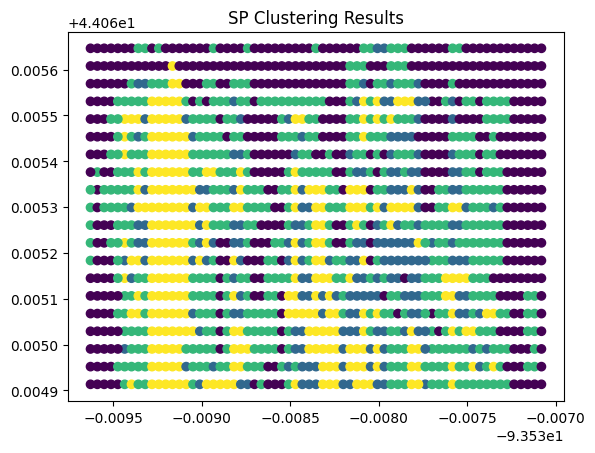

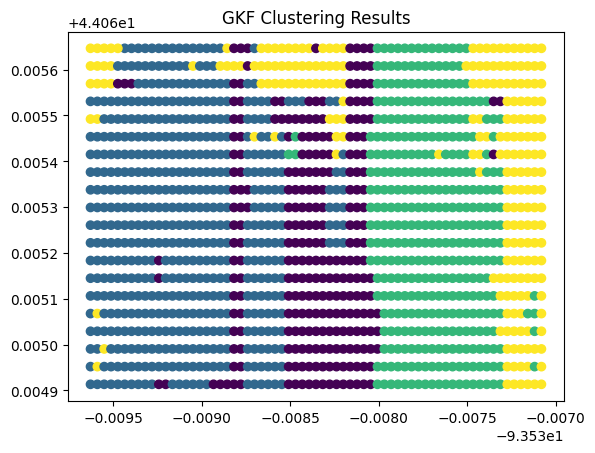

In [3]:
p = CombinedPreprocessor(drop=drop_cols)

indices_6182020 = pd.read_csv("../Datasets/Indices_Combined/2020/June_18_2020_New.csv")
indices_6232020 = pd.read_csv("../Datasets/Indices_Combined/2020/June_23_2020_New.csv")
indices_6302020 = pd.read_csv("../Datasets/Indices_Combined/2020/June_30_2020_New.csv")
indices_7062020 = pd.read_csv("../Datasets/Indices_Combined/2020/July_6_2020_New.csv")
clusters_2020 = pd.read_csv("../Datasets/Clusters/combined_2020_clustering.csv")['CLUSTER_ID'].to_numpy()

X_train_validate, X_test, Y_train_validate, Y_test = p.transform([indices_6182020, indices_6232020, indices_6302020], indices_7062020)

random_validator = RandomCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
gkf_validator = GroupKFoldCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, clusters=clusters_2020)
sp_validator = SpatialPlusCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
random_results = random_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)
gkf_results = gkf_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)
sp_results = sp_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)

display(random_results, gkf_results, sp_results)
sp_validator.display_clusters()
gkf_validator.display_clusters()


,Random,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.166758,0.063008,0.003670,0.006705
1,LR,TEST,0.272316,-1.545401,0.046724,0.850731
2,RF,CV,0.150136,0.240163,0.006151,0.043774
3,RF,TEST,0.211128,-0.488170,0.007524,0.105896
4,XGB,CV,0.162069,0.114197,0.002320,0.031173
5,XGB,TEST,0.221231,-0.668000,0.032889,0.487938


,GroupKFold,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.240348,-1.682655,0.128867,2.637433
1,LR,TEST,0.531459,-17.337619,0.517218,28.566752
2,RF,CV,0.203555,-0.720178,0.028429,0.505022
3,RF,TEST,0.212744,-0.518059,0.016368,0.226432
4,XGB,CV,0.190585,-0.476920,0.015255,0.296511
5,XGB,TEST,0.190818,-0.224690,0.017840,0.234826


,Spatial+,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.188458,-0.249179,0.020498,0.194270
1,LR,TEST,0.246602,-1.153984,0.061542,1.034160
2,RF,CV,0.169309,-0.019291,0.006991,0.174773
3,RF,TEST,0.199294,-0.332356,0.015516,0.200517
4,XGB,CV,0.184285,-0.236922,0.017424,0.402119
5,XGB,TEST,0.230298,-0.841682,0.046867,0.756880


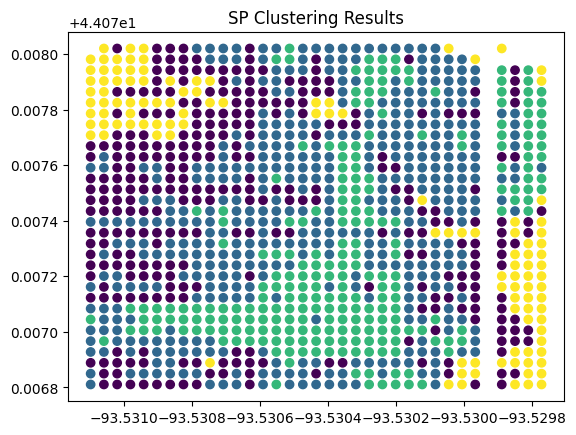

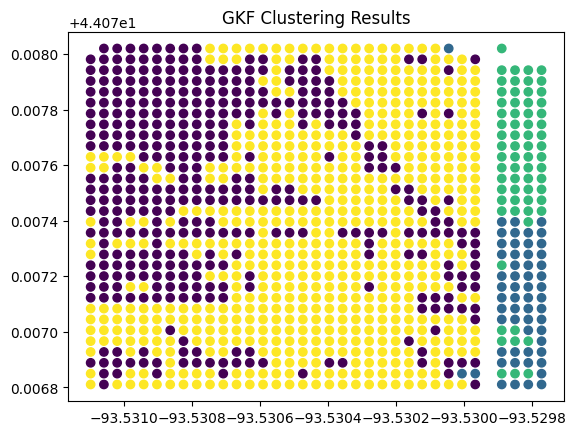

In [4]:
p1 = CombinedPreprocessor(drop=drop_cols)

indices_6162021 = pd.read_csv("../Datasets/Indices_Combined/2021/June_16_2021.csv")
indices_6222021 = pd.read_csv("../Datasets/Indices_Combined/2021/June_22_2021.csv")
indices_6302021 = pd.read_csv("../Datasets/Indices_Combined/2021/June_30_2021.csv")
indices_7122021 = pd.read_csv("../Datasets/Indices_Combined/2021/July_12_2021.csv")
clusters_2021 = pd.read_csv("../Datasets/Clusters/combined_2021_clustering.csv")['CLUSTER_ID'].to_numpy()

X_train_validate1, X_test1, Y_train_validate1, Y_test1 = p1.transform([indices_6162021, indices_6222021, indices_6302021], indices_7122021)

random_validator1 = RandomCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
gkf_validator1 = GroupKFoldCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, clusters=clusters_2021)
sp_validator1 = SpatialPlusCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
random_results1 = random_validator1.results(X_train_validate1, X_test1, Y_train_validate1, Y_test1)
gkf_results1 = gkf_validator1.results(X_train_validate1, X_test1, Y_train_validate1, Y_test1)
sp_results1 = sp_validator1.results(X_train_validate1, X_test1, Y_train_validate1, Y_test1)

display(random_results1, gkf_results1, sp_results1)
sp_validator1.display_clusters()
gkf_validator1.display_clusters()

,Random,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.132771,0.279218,0.008028,0.049877
1,LR,TEST,0.263370,-2.171436,0.054164,1.299900
2,RF,CV,0.131090,0.299745,0.010379,0.037728
3,RF,TEST,0.154522,-0.050100,0.007842,0.103921
4,XGB,CV,0.140765,0.186693,0.011323,0.104145
5,XGB,TEST,0.175727,-0.361860,0.012867,0.196948


,GroupKFold,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.153219,-0.916619,0.026176,1.027340
1,LR,TEST,0.285802,-2.884507,0.082888,1.854621
2,RF,CV,0.147081,-0.623122,0.036883,0.589112
3,RF,TEST,0.149823,0.003620,0.016338,0.221271
4,XGB,CV,0.162721,-0.998185,0.041913,0.734726
5,XGB,TEST,0.162162,-0.160766,0.012844,0.189628


,Spatial+,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.140634,-0.004992,0.028634,0.186403
1,LR,TEST,0.368925,-7.482648,0.239310,10.480520
2,RF,CV,0.165931,-0.431834,0.031135,0.336354
3,RF,TEST,0.201281,-1.089980,0.084440,1.849560
4,XGB,CV,0.199343,-1.080657,0.059058,0.816241
5,XGB,TEST,0.234613,-1.962653,0.111779,2.923094


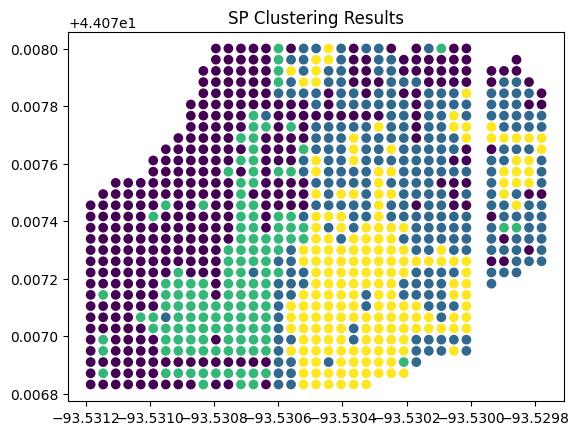

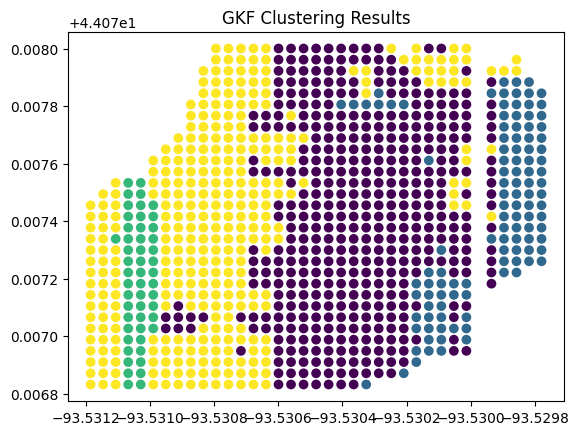

In [5]:
p2 = CombinedPreprocessor(drop=drop_cols)

indices_6152022 = pd.read_csv("../Datasets/Indices_Combined/2022/June_15_2022.csv")
indices_6232022 = pd.read_csv("../Datasets/Indices_Combined/2022/June_23_2022.csv")
indices_6282022 = pd.read_csv("../Datasets/Indices_Combined/2022/June_28_2022.csv")
indices_7132022 = pd.read_csv("../Datasets/Indices_Combined/2022/July_13_2022.csv")
clusters_2022 = pd.read_csv("../Datasets/Clusters/combined_2022_clustering.csv")['CLUSTER_ID'].to_numpy()

X_train_validate2, X_test2, Y_train_validate2, Y_test2 = p2.transform([indices_6152022, indices_6232022, indices_6282022], indices_7132022)

random_validator2 = RandomCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
gkf_validator2 = GroupKFoldCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, clusters=clusters_2022)
sp_validator2 = SpatialPlusCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
random_results2 = random_validator2.results(X_train_validate2, X_test2, Y_train_validate2, Y_test2)
gkf_results2 = gkf_validator2.results(X_train_validate2, X_test2, Y_train_validate2, Y_test2)
sp_results2 = sp_validator2.results(X_train_validate2, X_test2, Y_train_validate2, Y_test2)

display(random_results2, gkf_results2, sp_results2)
sp_validator2.display_clusters()
gkf_validator2.display_clusters()